# Stryker Crop — interaktywny (suwaki parametrow)

## Po co
Sztywne progi z pierwszej wersji zamienione na suwaki. Zmieniasz parametr -> widzisz kadr na zywo. Kazdy suwak celuje w konkretny objaw:

| Objaw | Suwak(i) |
|---|---|
| **Zoom** (kadry za ciasne) | `min_scale` + `kara_zoom` (miekka kara za male kadry) |
| **Dryf** (omija ludzi) | `stride` (gestosc siatki) |
| **Pomaga wszedzie** | `prog_istotnosci` + baseline losowy na zywo |
| **Proporcje** (panoramy vs kwadraty) | `kara_proporcje` |

## Jak uzywac
1. Uruchom setup (0-1)
2. Wgraj zdjecia do `/content/crop_input/`
3. Uruchom panel (2) — pojawia sie suwaki
4. Wybierz zdjecie z listy, kreç suwakami, obserwuj


## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q open_clip_torch ipywidgets 2>/dev/null


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 153.5 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image, ImageOps
import torch, open_clip
import ipywidgets as W
from IPython.display import display
np.set_printoptions(precision=4, suppress=True)

DRIVE = Path('/content/drive/MyDrive/fsa_data')
INPUT = Path('/content/crop_input'); INPUT.mkdir(exist_ok=True)

with np.load(DRIVE/'akt1_axes.npz') as d:
    v_hole, v_sharp = d['v_hole'], d['v_sharp']
with np.load(DRIVE/'akt2b_axes.npz') as d:
    v_clean3 = d['v_clean3']; v_bright = d['v_bright']; v_contrast = d['v_contrast']
Q, _ = np.linalg.qr(np.stack([v_hole, v_sharp, v_bright, v_contrast], axis=1))
def neutralize(e):
    e = np.atleast_2d(e)
    return e - (e @ Q) @ Q.T

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model = model.to(device).eval()
print(f'OK: CLIP na {device}. Wgraj zdjecia do {INPUT}')


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

OK: CLIP na cuda. Wgraj zdjecia do /content/crop_input


## 1. Funkcje scoringu (z parametryzacja)

In [ ]:
@torch.no_grad()
def raw_scores(pil, boxes, batch=96):
    out = np.zeros(len(boxes))
    for i in range(0, len(boxes), batch):
        ch = boxes[i:i+batch]
        tens = torch.stack([preprocess(pil.crop(b)) for b in ch]).to(device)
        e = model.encode_image(tens)
        e = (e/e.norm(dim=-1,keepdim=True)).float().cpu().numpy().astype(np.float64)
        out[i:i+len(ch)] = neutralize(e) @ v_clean3
    return out

def gen_boxes(Wd, Hd, min_scale, ar_range, stride_frac):
    # skale od 0.95 do min_scale (5 krokow), proporcje w zadanym zakresie
    scales = np.linspace(0.95, min_scale, 5)
    ar_lo, ar_hi = ar_range
    ars = [ar_lo, 1.0, ar_hi] if ar_lo < 1.0 < ar_hi else [ar_lo, ar_hi]
    boxes, metas = [], []
    for s in scales:
        for ar in ars:
            chh = int(min(Hd*s, Wd*s/ar)); cww = int(chh*ar)
            if cww>Wd or chh>Hd or cww<80 or chh<80: continue
            st = max(1, int(min(cww,chh)*stride_frac))
            for top in range(0, Hd-chh+1, st):
                for left in range(0, Wd-cww+1, st):
                    boxes.append((left,top,left+cww,top+chh))
                    metas.append((s, ar))
    return boxes, metas

def penalized(scores, metas, min_scale, kara_zoom, kara_prop, ar_neutral=1.0):
    # kara_zoom: odejmij proporcjonalnie do tego jak maly kadr (s blizej min_scale)
    # kara_prop: odejmij za odejscie ar od ar_neutral (na skali log)
    s_arr = np.array([m[0] for m in metas]); ar_arr = np.array([m[1] for m in metas])
    zoom_pen = kara_zoom * (0.95 - s_arr) / (0.95 - min_scale + 1e-9)   # 0 przy s=0.95, 1 przy min
    prop_pen = kara_prop * np.abs(np.log(ar_arr/ar_neutral))
    return scores - zoom_pen - prop_pen

print('Funkcje gotowe: raw_scores, gen_boxes, penalized')


Funkcje gotowe: raw_scores, gen_boxes, penalized


## 2. Panel interaktywny z suwakami

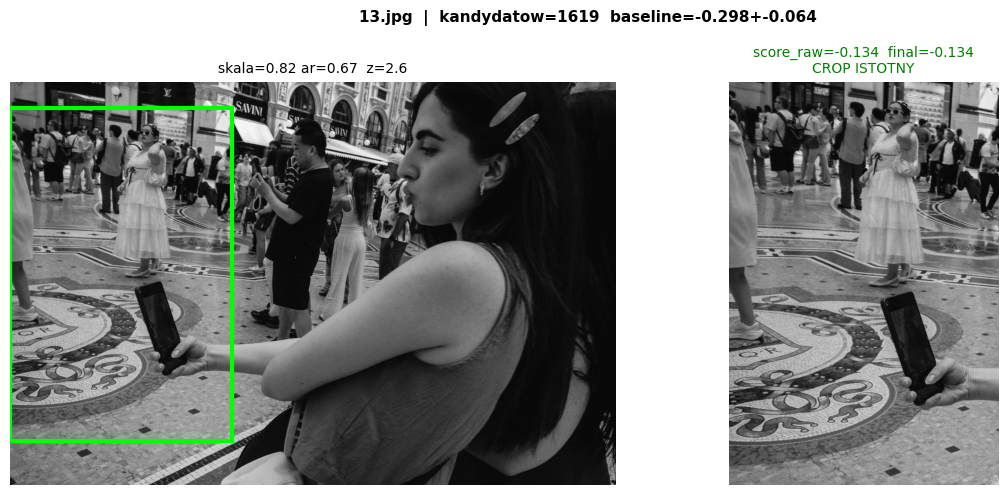

z-score nad baseline: 2.58  (prog=1.0)  ->  CROP ISTOTNY
kara_zoom odjela: 0.000, kara_prop: 0.000


Output()

In [ ]:
EXTS=('.jpg','.jpeg','.png','.webp')
files = sorted([f for f in INPUT.iterdir() if f.suffix.lower() in EXTS])
assert files, 'Wgraj zdjecia do /content/crop_input/'

# Cache: raw scores per zdjecie liczymy raz na dany zestaw boxow.
# Ale boxy zaleza od min_scale/stride/ar, wiec cache po (plik, geometria).
_cache = {}
def analyze(fname, min_scale, ar_lo, ar_hi, stride_frac):
    key = (fname, round(min_scale,3), round(ar_lo,3), round(ar_hi,3), round(stride_frac,3))
    if key in _cache: return _cache[key]
    pil = ImageOps.exif_transpose(Image.open(INPUT/fname)).convert('RGB')
    Wd,Hd = pil.size
    boxes, metas = gen_boxes(Wd,Hd, min_scale, (ar_lo,ar_hi), stride_frac)
    sc = raw_scores(pil, boxes)
    # baseline losowy: 200 losowych kadrow z pelnej przestrzeni
    rng = np.random.RandomState(0)
    ri = rng.choice(len(boxes), min(200,len(boxes)), replace=False)
    base_mean, base_std = sc[ri].mean(), sc[ri].std()
    res = dict(pil=pil, boxes=boxes, metas=metas, sc=sc, base_mean=base_mean, base_std=base_std)
    _cache[key] = res
    return res

out = W.Output()
def render(fname, min_scale, ar_lo, ar_hi, stride_frac, kara_zoom, kara_prop, prog_ist):
    with out:
        out.clear_output(wait=True)
        r = analyze(fname, min_scale, ar_lo, ar_hi, stride_frac)
        pil, boxes, metas, sc = r['pil'], r['boxes'], r['metas'], r['sc']
        final = penalized(sc, metas, min_scale, kara_zoom, kara_prop)
        bi = int(np.argmax(final))
        box = boxes[bi]
        # istotnosc: o ile best bije baseline losowy (w jednostkach std)
        z = (sc[bi] - r['base_mean']) / (r['base_std'] + 1e-9)
        passes = z > prog_ist
        fig, ax = plt.subplots(1,2, figsize=(12,5))
        ax[0].imshow(pil); ax[0].axis('off')
        l,t,rr,b = box
        col = 'lime' if passes else 'orange'
        ax[0].add_patch(Rectangle((l,t),rr-l,b-t, fill=False, edgecolor=col, lw=3))
        ax[0].set_title(f'skala={metas[bi][0]:.2f} ar={metas[bi][1]:.2f}  z={z:.1f}', fontsize=10)
        ax[1].imshow(pil.crop(box)); ax[1].axis('off')
        verdict = 'CROP ISTOTNY' if passes else 'ponizej progu (pelny OK / brak tresci)'
        ax[1].set_title(f'score_raw={sc[bi]:+.3f}  final={final[bi]:+.3f}\n{verdict}',
                        fontsize=10, color=('green' if passes else 'darkorange'))
        plt.suptitle(f'{fname}  |  kandydatow={len(boxes)}  baseline={r["base_mean"]:+.3f}+-{r["base_std"]:.3f}',
                     fontsize=11, fontweight='bold')
        plt.tight_layout(); plt.show()
        print(f'z-score nad baseline: {z:.2f}  (prog={prog_ist})  ->  {verdict}')
        print(f'kara_zoom odjela: {kara_zoom*(0.95-metas[bi][0])/(0.95-min_scale+1e-9):.3f}, '
              f'kara_prop: {kara_prop*abs(np.log(metas[bi][1])):.3f}')

# Suwaki
w_file = W.Dropdown(options=[f.name for f in files], description='zdjecie')
w_mins = W.FloatSlider(value=0.45, min=0.25, max=0.9, step=0.05, description='min_scale')
w_arlo = W.FloatSlider(value=0.667, min=0.4, max=1.0, step=0.05, description='ar_lo')
w_arhi = W.FloatSlider(value=1.5, min=1.0, max=2.5, step=0.05, description='ar_hi')
w_str  = W.FloatSlider(value=0.12, min=0.05, max=0.25, step=0.01, description='stride')
w_kz   = W.FloatSlider(value=0.0, min=0.0, max=0.3, step=0.01, description='kara_zoom')
w_kp   = W.FloatSlider(value=0.0, min=0.0, max=0.3, step=0.01, description='kara_prop')
w_prog = W.FloatSlider(value=1.0, min=0.0, max=4.0, step=0.25, description='prog_ist(z)')

ui = W.VBox([w_file, W.HBox([w_mins,w_str]), W.HBox([w_arlo,w_arhi]),
            W.HBox([w_kz,w_kp]), w_prog])
link = W.interactive_output(render, dict(fname=w_file, min_scale=w_mins, ar_lo=w_arlo,
       ar_hi=w_arhi, stride_frac=w_str, kara_zoom=w_kz, kara_prop=w_kp, prog_ist=w_prog))
display(ui, out)




## 3. Jak diagnozowac suwakami

**Zoom (za ciasne)**: podnos `kara_zoom` (0.05->0.15). Kadr powinien sie rozszerzac. Jesli mimo duzej kary os wciaz wybiera ciasny kadr — to znaczy, ze tam NAPRAWDE jest sygnal (duzo ludzi), nie artefakt.

**Dryf (omija ludzi)**: zmniejsz `stride` (0.12->0.06) dla gestszej siatki. Jesli ramka trafi na ludzi — okno wczesniej ich przeskakiwalo. Jesli nie — os faktycznie nie widzi tam ludzkiej historii.

**Pomaga wszedzie**: podnos `prog_ist` (z-score). Na zdjeciu z ludzmi z powinno byc wysokie (>2), na pustym pejzazu niskie (<1). Prog oddziela jedno od drugiego. Ramka pomaranczowa = ponizej progu = uczciwe 'brak poprawy'.

**Proporcje**: podnos `kara_prop` jesli os ucieka w panoramy/paski. Zobaczysz, czy woli kwadratowe kompozycje z ludzmi.

### Co to mowi o osi
Jesli dobre kadry wymagaja DUZEJ kary_zoom, zeby nie byly ciasne — os myli 'ludzka historie' z 'duzo twarzy'. Jesli sensowne kadry wychodza przy zerowej karze — os naprawde koduje kompozycje (wsparcie T2). To sam w sobie wynik badawczy.
